In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/Users/jake/sbx/paragon/lib')
sys.path.append('.')

import math
from datetime import datetime, timedelta, date

#stocks = ['AAPL', 'ALTM', 'AMAT', 'AMZN', 'BA', 'BAC', 'BK', 'BMY', 'BSX', 'CLF', 'CNC', 'CRWD', 'DIS', 'EA', 'EOG', 'FCX', 'FFXDF', 'FSLR', 'GILD', 'GOOGL', 'HAL', 'HSY', 'JPM', 'LLY', 'MDB', 'META', 'MP', 'MSFT', 'NEM', 'NVDA', 'NXPI', 'PCG', 'PWR', 'QCOM', 'RTX', 'SHEL', 'SLV', 'UBER', 'WMT', 'XBI']
#stocks = ['IWF', 'MTUM', 'USMV', 'VYM', 'IWD', 'IJR']
# stocks = ['AAL', 'ADBE', 'AMD', 'BABA', 'C', 'AMZN', 'GOOGL', 'MSFT', 'SPCE', 'AAPL', 'FB', 'IPO', 'ARKK', 'TSLA', 'SLV']

# Peptide
stocks = ['HIMS', 'NVO', 'ZLDPF', 'BCHMY', 'LLY', 'NVS']

num_days = 250

start_date = date.today() - timedelta(days = math.ceil((num_days/(5/7))))



In [2]:
import yfinance as yf

# Yahoo Finance interval mapping (Polygon used 'day'/'week'/'month' timespans)
_YF_INTERVALS = {'day': '1d', 'week': '1wk', 'month': '1mo'}

def history(symbol, start_date, timespan='day'):
    date_format = "%Y-%m-%d"

    interval = _YF_INTERVALS.get(timespan, '1d')
    end_date = date.today() + timedelta(days=1)  # yfinance end date is exclusive

    df = yf.download(
        symbol,
        start=start_date.strftime(date_format),
        end=end_date.strftime(date_format),
        interval=interval,
        auto_adjust=False,
        progress=False,
    )

    if df is None or df.empty:
        raise ValueError("Yahoo Finance history for %s is empty" % symbol)

    # Recent yfinance versions return MultiIndex columns even for a single ticker
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.rename(columns={
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Adj Close": "adj_close",
        "Volume": "volume",
    })

    df.index.name = None

    return df


In [3]:
# Pull Data

ohlcvs = {}
for stock in stocks:
    print("%s" % (stock))
    ohlcv = history(stock, start_date)
    ohlcvs[stock] = ohlcv['close']
    
df = pd.DataFrame(ohlcvs)
# print(str(df))

    

HIMS
NVO
ZLDPF
BCHMY
LLY
NVS


# HRP

In [4]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from scipy.spatial.distance import squareform


class HierarchicalRiskParity:
    """Self-contained drop-in for mlfinlab's HRP (Lopez de Prado 2016).

    Implements the subset used in this notebook: allocate(asset_names, asset_prices,
    linkage=...), plus .weights (1xN DataFrame, original column order) and .clusters
    (scipy linkage matrix). No external dependency on mlfinlab/sklearn.
    """

    def __init__(self):
        self.weights = None
        self.clusters = None
        self.seriated_assets = None

    @staticmethod
    def _get_cluster_var(cov, items):
        cov_ = cov.loc[items, items]
        ivp = 1.0 / np.diag(cov_.values)
        ivp /= ivp.sum()
        return float(ivp @ cov_.values @ ivp)

    @staticmethod
    def _quasi_diag(link, n):
        link = link.astype(int)
        sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
        while sort_ix.max() >= n:
            sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
            df0 = sort_ix[sort_ix >= n]
            i, j = df0.index, df0.values - n
            sort_ix[i] = link[j, 0]
            sort_ix = pd.concat([sort_ix, pd.Series(link[j, 1], index=i + 1)])
            sort_ix = sort_ix.sort_index()
            sort_ix.index = range(sort_ix.shape[0])
        return sort_ix.tolist()

    def _recursive_bisection(self, cov, sorted_assets):
        w = pd.Series(1.0, index=sorted_assets)
        clusters = [sorted_assets]
        while clusters:
            clusters = [c[s:e] for c in clusters
                        for s, e in ((0, len(c) // 2), (len(c) // 2, len(c)))
                        if len(c) > 1]
            for i in range(0, len(clusters), 2):
                c0, c1 = clusters[i], clusters[i + 1]
                v0, v1 = self._get_cluster_var(cov, c0), self._get_cluster_var(cov, c1)
                alpha = 1 - v0 / (v0 + v1)
                w[c0] *= alpha
                w[c1] *= 1 - alpha
        return w

    def allocate(self, asset_names=None, asset_prices=None, linkage='single', **kwargs):
        prices = asset_prices.copy()
        returns = prices.pct_change().dropna(how='all')
        cov, corr = returns.cov(), returns.corr()
        n = corr.shape[0]
        dist = np.sqrt(((1 - corr).clip(lower=0) / 2))
        self.clusters = scipy_linkage(squareform(dist.values, checks=False), method=linkage)
        order = self._quasi_diag(self.clusters, n)
        self.seriated_assets = corr.index[order].tolist()
        w = self._recursive_bisection(cov, self.seriated_assets).reindex(corr.index)
        self.weights = pd.DataFrame(w).T          # 1xN, original column order
        self.weights.index = [0]
        return None


hrp = HierarchicalRiskParity()

res = hrp.allocate(np.array(df.columns.tolist()), df, linkage='ward')

weights = hrp.weights.T
weights.columns = ['weight']
print(weights.index.tolist())


['HIMS', 'NVO', 'ZLDPF', 'BCHMY', 'LLY', 'NVS']


In [5]:
import pprint
pp = pprint.PrettyPrinter(indent=4)

portfolio_size_all = 10000

portfolio_size = portfolio_size_all * 1.0
portfolio_size_all_weather = portfolio_size_all - portfolio_size

# for stock, weight in weights['weight'].sort_values(ascending=False).iteritems():
#     amount = portfolio_size * weight
 
#     print('{a}\t {b:5,.2f}%\t {c:10,.0f}'.format(a=stock, b=weight*100.0, c=amount))

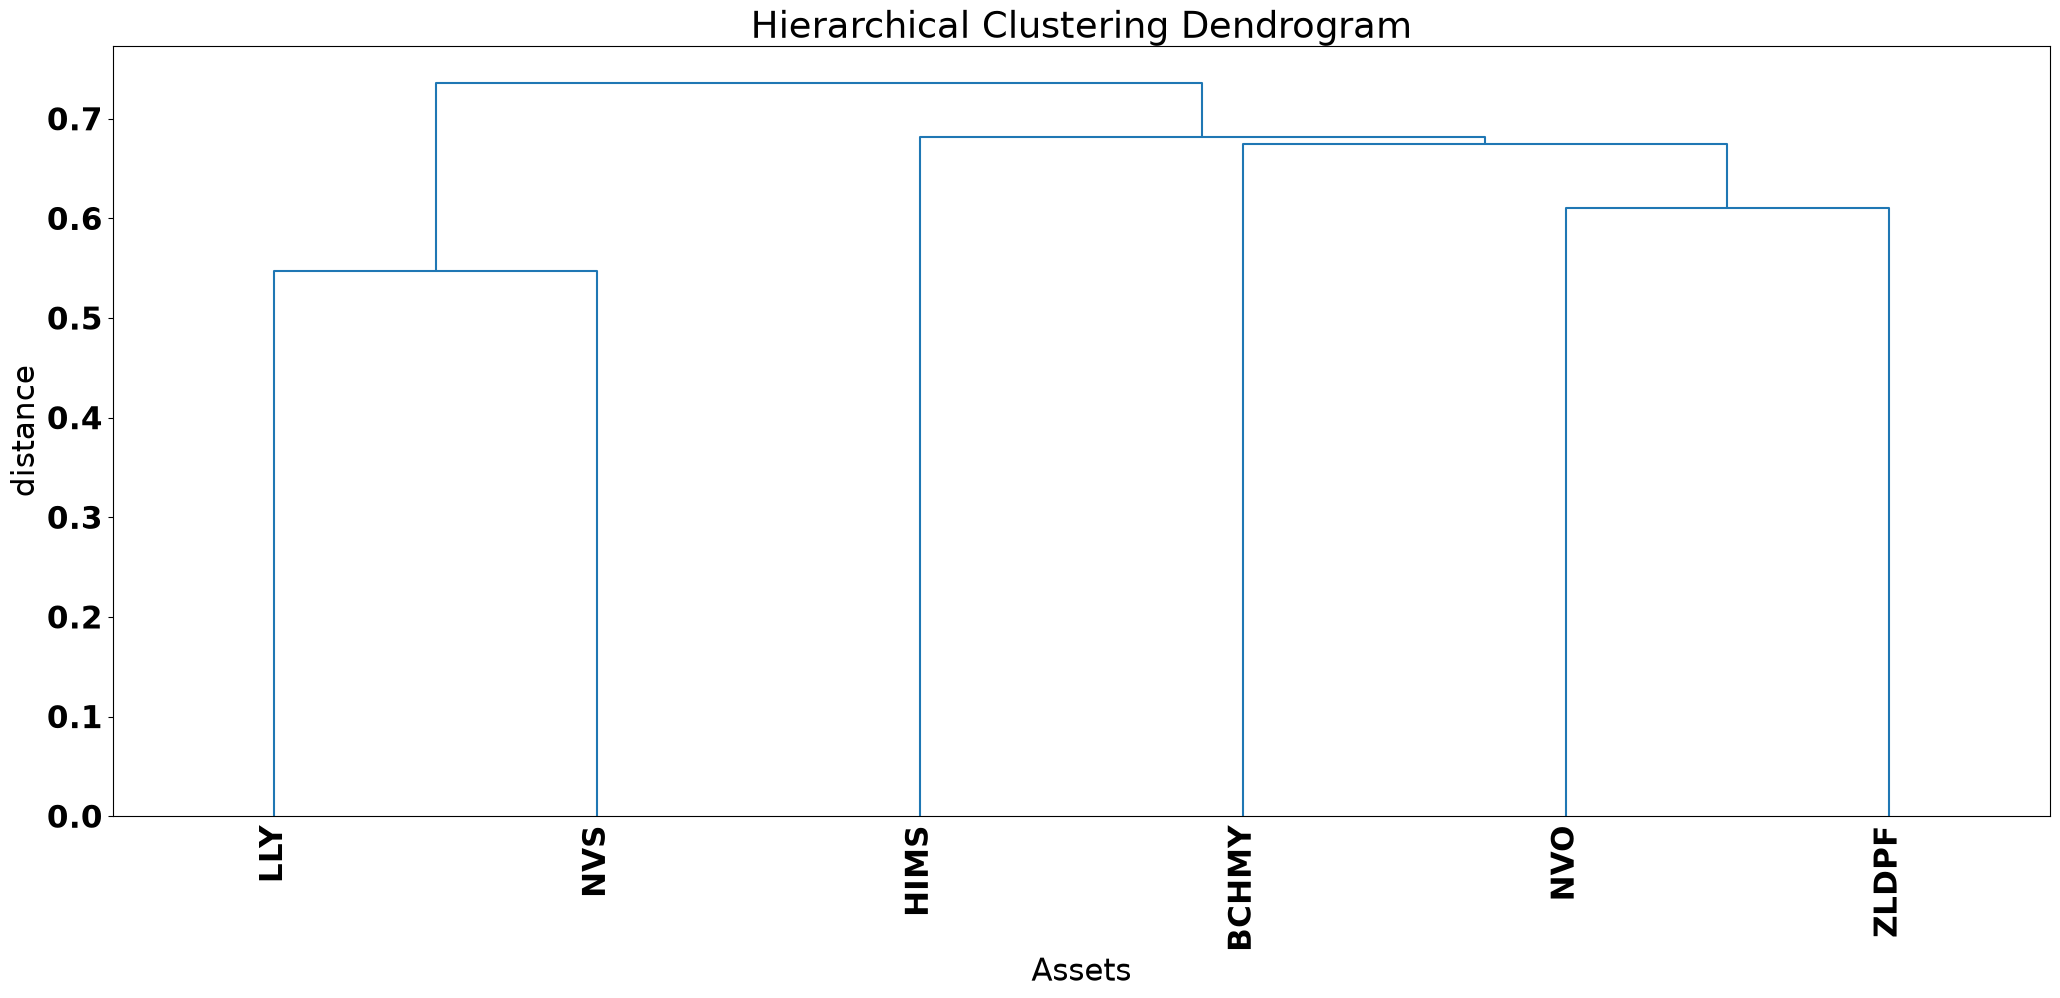

In [6]:
# calculate full dendrogram
from matplotlib import pyplot as plt
font = {#'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}
plt.rc('font', **font)
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Assets')
plt.ylabel('distance')
dendrogram(
    hrp.clusters,
    labels=weights.index.tolist(),
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=22.,  # font size for the x axis labels
)
plt.show()

In [7]:
# Before
print('{a:6}\t {b:>7}\t {c:>10}\t {d:>9}'.format(a='ticker', b='weight', c='amount', d='shares'))
for stock, weight in weights['weight'].sort_values(ascending=False).items():
    amount = portfolio_size * weight
    price = df[stock].iloc[-1]
    shares = amount / price

    print('{a:6}\t {b:5,.2f}%\t {c:10,.0f}\t {d:9,.2f}'.format(
        a=stock, b=weight*100.0, c=amount, d=shares))

ticker	  weight	     amount	    shares
NVS   	 54.23%	      5,423	     35.72
LLY   	 16.85%	      1,685	      1.51
BCHMY 	 12.26%	      1,226	    131.17
NVO   	  8.32%	        832	     18.71
ZLDPF 	  5.38%	        538	       nan
HIMS  	  2.95%	        295	      9.38


In [8]:
# All Weather Ratios
all_weather = {
    'VTI': 0.3,
    'TLT': 0.4,
    'IEI': 0.15,
    'DBC': 0.075,
    'GLD': 0.075
}

for symbol in all_weather:
    amount = all_weather[symbol] * portfolio_size_all_weather
    print('{a}\t {b:5,.2f}%\t {c:10,.0f}'.format(a=symbol, b=all_weather[symbol]*100.0, c=amount))


VTI	 30.00%	          0
TLT	 40.00%	          0
IEI	 15.00%	          0
DBC	  7.50%	          0
GLD	  7.50%	          0


In [29]:
from scipy.cluster.hierarchy import fcluster
from matplotlib import pyplot as plt


def print_clusters(prices, Z, k, plot=False, plot_threshold=1):
    """Cut the HRP dendrogram into k clusters and optionally plot each
    cluster's normalized cumulative-return paths.

    prices : DataFrame of close prices, one column per asset, in the SAME
             column order used to build the linkage matrix Z (i.e. ``df``).
    Z      : scipy linkage matrix (``hrp.clusters``).
    k      : number of clusters to extract (maxclust criterion).
    """
    labels = fcluster(Z, k, criterion='maxclust')
    s = pd.Series(labels, index=prices.columns)

    for c in sorted(s.unique()):
        members = s[s == c].index.tolist()
        print("Cluster %d: %d entries -> %s" % (c, len(members), members))
        if plot and len(members) >= plot_threshold:
            norm = prices[members] / prices[members].iloc[0] - 1
            ax = norm.plot(figsize=(15, 6), title="Cluster %d" % c)
            ax.set_ylabel("cumulative return")
            plt.show()

Cluster 1: 1 entries -> ['HIMS']


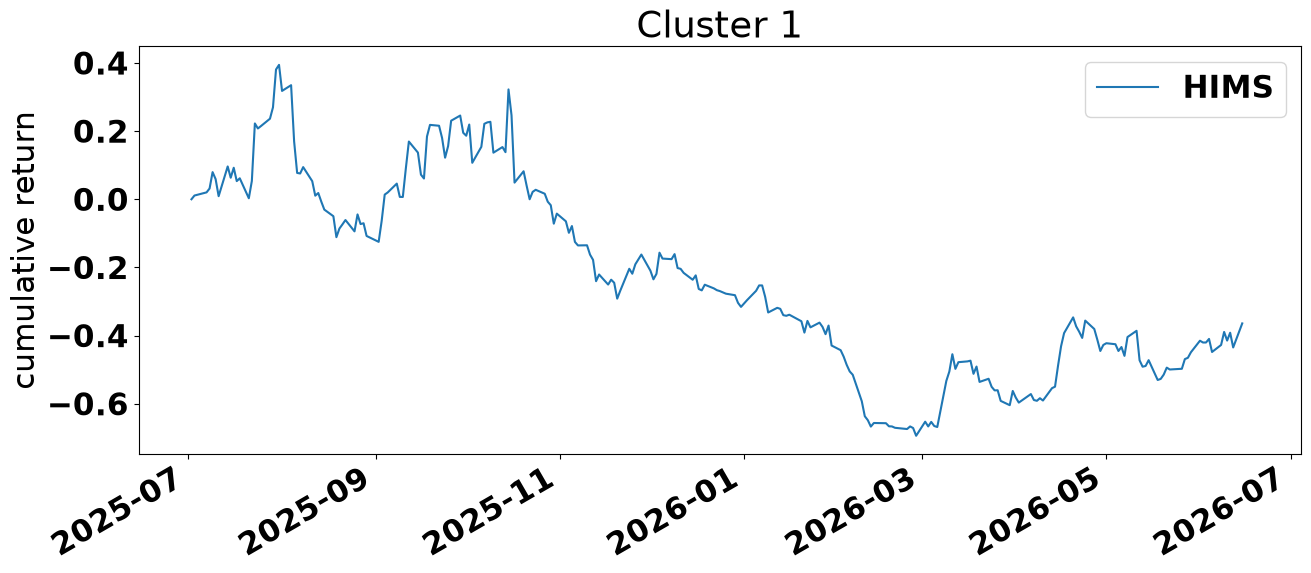

Cluster 2: 1 entries -> ['NVO']


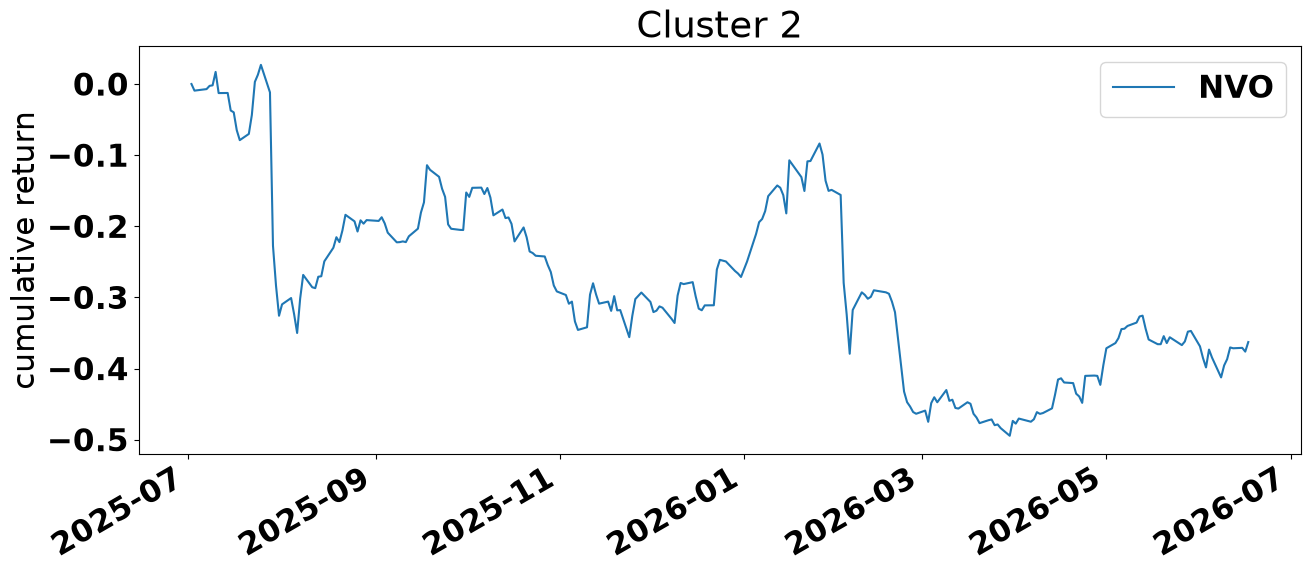

Cluster 3: 1 entries -> ['ZLDPF']


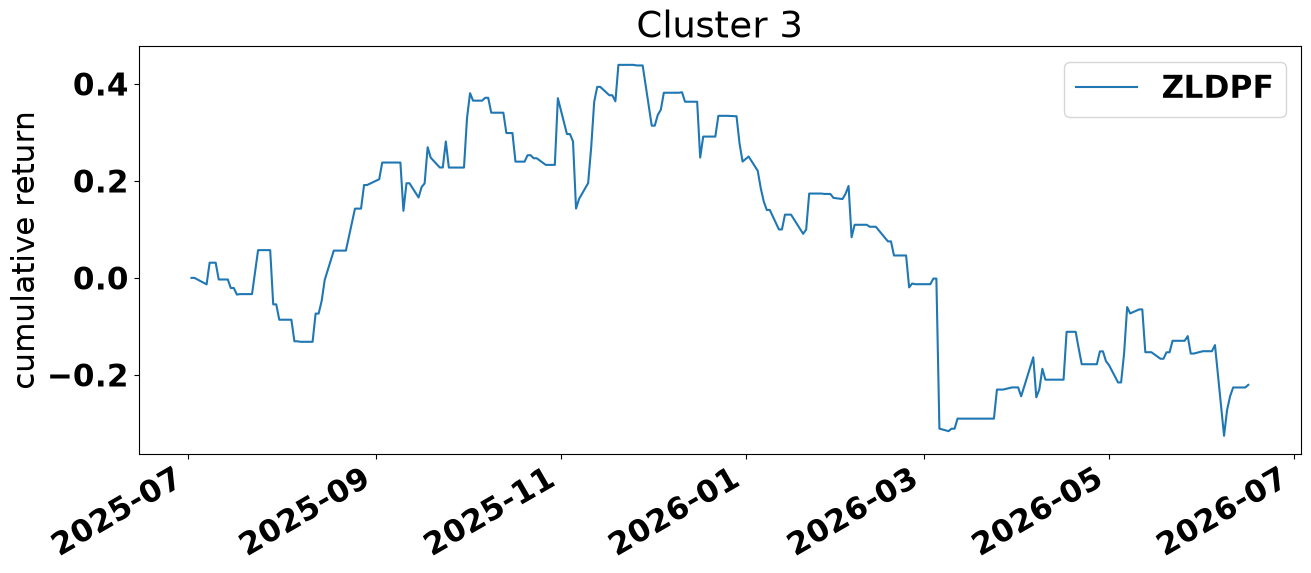

In [30]:
# Cut the HRP tree into k clusters and plot each cluster's normalized price paths.
number_of_clusters_to_use = [3]
for k in number_of_clusters_to_use:
    print_clusters(df, hrp.clusters, k, plot=True)